### Voting Regressor

In [2]:
from sklearn.datasets import load_diabetes
import pandas as pd 

In [4]:
X,y=load_diabetes(return_X_y=True)

In [5]:
X.shape

(442, 10)

In [6]:
y.shape

(442,)

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

In [16]:
lr=LinearRegression()
dt=DecisionTreeRegressor()
svr=SVR()

In [17]:
estimators=[("lr",lr),("dt",dt),("svr",svr)]

In [18]:
for estimator in estimators:
    scores=cross_val_score(estimator[1],X,y,scoring='r2',cv=10)
    print(estimator[0],np.round(np.mean(scores),2))

lr 0.46
dt -0.26
svr 0.15


In [19]:
from sklearn.ensemble import VotingRegressor

In [20]:
vr=VotingRegressor(estimators)
scores=cross_val_score(vr,X,y,scoring="r2",cv=10)
print("VotingRegressor",np.round(np.mean(scores),2))

VotingRegressor 0.34


In [21]:
for i in range (1,4):
    for j in range (1,4):
        for k in range (1,4):
            vr=VotingRegressor(estimators,weights=[i,j,k])
            scores=cross_val_score(vr,X,y,scoring="r2",cv=10)
            print("for i{},j{},k{}".format(i,j,k),np.round(np.mean(scores),2))

for i1,j1,k1 0.33
for i1,j1,k2 0.34
for i1,j1,k3 0.32
for i1,j2,k1 0.27
for i1,j2,k2 0.29
for i1,j2,k3 0.29
for i1,j3,k1 0.21
for i1,j3,k2 0.26
for i1,j3,k3 0.28
for i2,j1,k1 0.39
for i2,j1,k2 0.38
for i2,j1,k3 0.36
for i2,j2,k1 0.34
for i2,j2,k2 0.34
for i2,j2,k3 0.34
for i2,j3,k1 0.27
for i2,j3,k2 0.29
for i2,j3,k3 0.32
for i3,j1,k1 0.43
for i3,j1,k2 0.41
for i3,j1,k3 0.39
for i3,j2,k1 0.36
for i3,j2,k2 0.38
for i3,j2,k3 0.37
for i3,j3,k1 0.33
for i3,j3,k2 0.33
for i3,j3,k3 0.34


### Voting Classifier 

In [23]:
import numpy as np
import pandas as pd 
from sklearn.datasets import load_iris

In [26]:
iris=load_iris()

In [34]:
df=pd.DataFrame(iris.data,columns=iris.feature_names)

In [35]:
df["target"]=iris.target

In [36]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [38]:
df.shape

(150, 5)

In [41]:
new_df = df[df["target"] != 0][
    ["sepal length (cm)", "sepal width (cm)", "target"]
]

In [45]:
new_df.head()

,sepal length (cm),sepal width (cm),target
50,7.0,3.2,1
51,6.4,3.2,1
52,6.9,3.1,1
53,5.5,2.3,1
54,6.5,2.8,1


In [46]:
X=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [49]:
lr=LogisticRegression()
knn=KNeighborsClassifier()
rn=RandomForestClassifier()

In [57]:
estimators=[("lr",lr),("kn",knn),("rn",rn)]

In [58]:
for estimator in estimators:
    score=cross_val_score(estimator[1],X,y,cv=10,scoring="accuracy")
    print(estimator[0],np.round(np.mean(score),2))

lr 0.81
kn 0.76
rn 0.71


In [66]:
from sklearn.ensemble import VotingClassifier
vr=VotingClassifier(estimators=estimators,voting="hard")
x=cross_val_score(vr,X,y,cv=10,scoring="accuracy")
print("voting classifier",np.round(np.mean(x),2))

voting classifier 0.77


In [63]:
vr=VotingClassifier(estimators=estimators,voting="soft")
x=cross_val_score(vr,X,y,cv=10,scoring="accuracy")
print("voting classifier",np.round(np.mean(x),2))

voting classifier 0.77


Weighted Voting

In [69]:
for i in range (1,4):
    for j in range(1,4):
        for k in range(1,4):
            vr=VotingClassifier(estimators=estimators,voting="soft",weights=[i,j,k])
            s=cross_val_score(vr,X,y,cv=10,scoring="accuracy")
            print("for i={},j={},k={}".format(i,j,k),np.round(np.mean(s),2))

for i=1,j=1,k=1 0.77
for i=1,j=1,k=2 0.76
for i=1,j=1,k=3 0.74
for i=1,j=2,k=1 0.77
for i=1,j=2,k=2 0.75
for i=1,j=2,k=3 0.75
for i=1,j=3,k=1 0.76
for i=1,j=3,k=2 0.75
for i=1,j=3,k=3 0.75
for i=2,j=1,k=1 0.77
for i=2,j=1,k=2 0.76
for i=2,j=1,k=3 0.75
for i=2,j=2,k=1 0.77
for i=2,j=2,k=2 0.77
for i=2,j=2,k=3 0.77
for i=2,j=3,k=1 0.77
for i=2,j=3,k=2 0.77
for i=2,j=3,k=3 0.77
for i=3,j=1,k=1 0.8
for i=3,j=1,k=2 0.79
for i=3,j=1,k=3 0.75
for i=3,j=2,k=1 0.78
for i=3,j=2,k=2 0.77
for i=3,j=2,k=3 0.77
for i=3,j=3,k=1 0.79
for i=3,j=3,k=2 0.76
for i=3,j=3,k=3 0.77



Classifiers of Same Algo

In [70]:
from sklearn.svm import SVC

In [71]:
s1=SVC(kernel="poly",degree=1)
s2=SVC(kernel="poly",degree=2)
s3=SVC(kernel="poly",degree=3)
s4=SVC(kernel="poly",degree=4)
s5=SVC(kernel="poly",degree=5)

In [72]:
estimators=[("svc1",s1),("svc2",s2),("svc3",s3),("svc4",s4),("svc5",s5)]

In [73]:
for estimator in estimators:
    s=cross_val_score(estimator[1],X,y,cv=10,scoring="accuracy")
    print(estimator[0],np.round(np.mean(s),2))

svc1 0.82
svc2 0.81
svc3 0.81
svc4 0.8
svc5 0.79


### Bagging 

In [99]:
from sklearn.datasets import load_iris
df=pd.DataFrame(iris.data,columns=iris.feature_names)

In [100]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [101]:
df["target"]=iris.target

In [102]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [103]:
df=df[df["target"]!=0][["sepal length (cm)","sepal width (cm)","target"]]

In [104]:
df.head()

,sepal length (cm),sepal width (cm),target
50,7.0,3.2,1
51,6.4,3.2,1
52,6.9,3.1,1
53,5.5,2.3,1
54,6.5,2.8,1


In [105]:
df=df.sample(100)
df_train=df.iloc[:60,:].sample(10)
df_val=df.iloc[60:80,:].sample(5)
df_test=df.iloc[80:,:].sample(5)

In [106]:
df_val

,sepal length (cm),sepal width (cm),target
109,7.2,3.6,2
122,7.7,2.8,2
57,4.9,2.4,1
112,6.8,3.0,2
148,6.2,3.4,2


In [108]:
X_test=df_val.iloc[:,:2].values
y_test=df_val.iloc[:,-1].values

Case1:Bagging

In [114]:
from sklearn.tree import DecisionTreeClassifier

In [136]:
df_bag=df_train.sample(8,replace=True)
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal length (cm),sepal width (cm),target
130,7.4,2.8,2
90,5.5,2.6,1
69,5.6,2.5,1
90,5.5,2.6,1
69,5.6,2.5,1
127,6.1,3.0,2
130,7.4,2.8,2
96,5.7,2.9,1


In [115]:
dt_bag1=DecisionTreeClassifier()

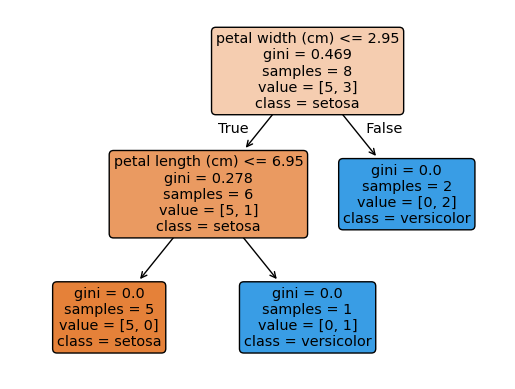

1.0


c:\Users\ANANT\OneDrive\Desktop\library\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [127]:
evaluate(dt_bag1,X,y)

In [125]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score

In [126]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(
    clf,
    feature_names=iris.feature_names[2:],
    class_names=iris.target_names,
    filled=True,
    rounded=True
    )

    plt.show()
    y_pred=clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

In [129]:
df_bag=df_train.sample(8,replace=True)
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal length (cm),sepal width (cm),target
70,5.9,3.2,1
90,5.5,2.6,1
54,6.5,2.8,1
138,6.0,3.0,2
50,7.0,3.2,1
70,5.9,3.2,1
50,7.0,3.2,1
138,6.0,3.0,2


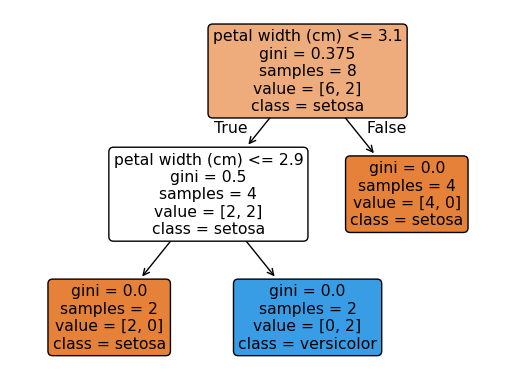

0.4


c:\Users\ANANT\OneDrive\Desktop\library\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [130]:
dt_bag2=DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [131]:
df_test

,sepal length (cm),sepal width (cm),target
95,5.7,3.0,1
128,6.4,2.8,2
123,6.3,2.7,2
88,5.6,3.0,1
64,5.6,2.9,1


In [134]:
print("prediction1",dt_bag1.predict(np.array([6.3,2.9]).reshape(1,2)))
print("prediction2",dt_bag2.predict(np.array([6.3,2.9]).reshape(1,2)))

prediction1 [1]
prediction2 [2]


c:\Users\ANANT\OneDrive\Desktop\library\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\ANANT\OneDrive\Desktop\library\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Pasting (in pasting the row sampling is done without row sampling i.e. no repetition of rows)

In [137]:
df_train.sample(8)

,sepal length (cm),sepal width (cm),target
96,5.7,2.9,1
127,6.1,3.0,2
130,7.4,2.8,2
54,6.5,2.8,1
103,6.3,2.9,2
90,5.5,2.6,1
50,7.0,3.2,1
69,5.6,2.5,1


Random Subspaces(columns sampling i.e. columns are selected differently)